In [2]:
import numpy as np
import pandas as pd
import sqlite3
import json
import os
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d
from scipy.io import wavfile
import h5py

In [3]:
db_path = r"C:\Users\tmerri03\Desktop\Temp Neural Files\neurons.db"

In [4]:
con = sqlite3.connect(db_path)
cur = con.cursor()

cur.execute('''
               SELECT session_id, unit_id, spike_width_pp, spike_width_hw, spike_file, stimulus_file
               FROM neurons
               WHERE manual_isi_1 < ?
               AND spike_width_pp IS NOT NULL
               AND spike_width_hw IS NOT NULL
               AND label = ?
               ''', (1,'auditory'))
neurons = cur.fetchall()

In [5]:
# --- list birds ---
birds = []
for session_id, unit_id, spike_width_pp, spike_width_hw, spike_file, stimulus_file in neurons:
    birds.append(session_id.split(' ')[0])
bird_ids = pd.unique(pd.Series(birds))
print(bird_ids)

['k53k54' 'o13g88' 'p26b39' 'p30y70' 'pi26pi17' 'w90b25' 'w37k30' 'w85k85']


In [6]:
# --- bird class list ---
trained_birds = ['k53k54', 'o13g88', 'w85k85']
yoked_birds = ['w37k30']
naive_birds = ['p26b39', 'p30y70', 'pi26pi17']

In [7]:
# --- sort neurons by bird class
for i, tt in enumerate(neurons):
    bird_id = tt[0].split(" ")[0]

    if neurons[i][-1] == 'trained' or neurons[i][-1] == 'yoked' or neurons[i][-1] == 'naive':
        continue

    if bird_id == 'k53k54' or bird_id == 'pi26pi17'or bird_id == 'w90b25':
        neurons[i] = tt + ('ignore',)
        continue

    if bird_id in trained_birds:
        neurons[i] = tt + ('trained',)
    elif bird_id in yoked_birds:
        neurons[i] = tt + ('yoked',)
    elif bird_id in naive_birds:
        neurons[i] = tt + ('naive',)
    else:
        print(f"bird id {bird_id} not in bird class lists!")

In [8]:
# --- find repeated stimuli over all recordings (if any) ---
overlapping_stim = None

for session_id, unit_id, spike_width_pp, spike_width_hw, spike_file, stimulus_file, status in neurons:
    if status != 'ignore':
        stim_path = os.path.join(stimulus_file, '..', 'stimuli.json')

        with open(stim_path, "r") as f:
            stim_data = pd.DataFrame(json.load(f))
            unique_stim = set(stim_data['Stimuli Type'])

        if overlapping_stim is None:
            overlapping_stim = unique_stim
        else:
            overlapping_stim &= unique_stim

print(f'There are {len(overlapping_stim)} played in every recording. Set which one to focus on.')
print(overlapping_stim)

There are 3 played in every recording. Set which one to focus on.
{'White Noise', 'ZF A 180ms REG', 'ZF A 180ms Omit'}


C:\Users\tmerri03\AppData\Local\Temp\ipykernel_40724\628611539.py:13: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, sound = wavfile.read(stim_fp)  # sound is a numpy array


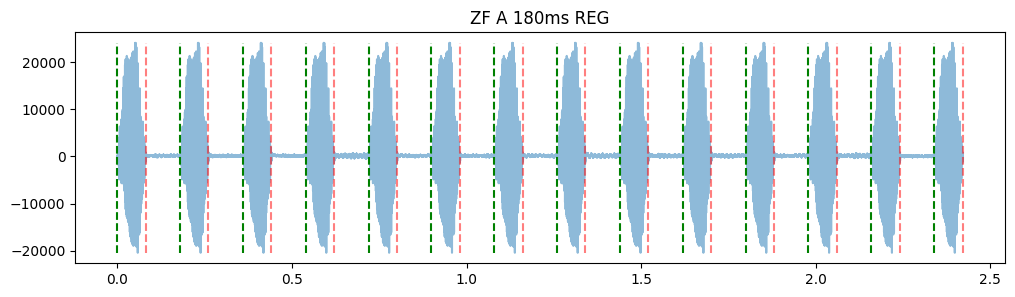

In [9]:
stimulus = 'ZF A 180ms REG'

fig, ax = plt.subplots(1,1, figsize=(12, 3))
stim_lib = r'R:\Data\tyler\Recordings\Stim\Stimuli Library'
stim_fp = os.path.join(stim_lib, f'{stimulus}.wav')

if not stim_fp.endswith('.wav'):
        stim_fp += '.wav'

if not os.path.exists(stim_fp):
    print("cannot find stim file in stimulus library...")
else:
    sample_rate, sound = wavfile.read(stim_fp)  # sound is a numpy array
    if len(sound.shape) == 2:
        sound = sound[:, 0]
    time = np.arange(len(sound)) / sample_rate

    #analyze beats by rms
    rms_values, rms_time = [], []
    chunk_size = int(2 / 1000 * sample_rate)
    sound = sound.astype(np.float64)
    for start in range(0, len(sound), chunk_size):
        chunk = sound[start:start + chunk_size]
        if len(chunk) == 0:
            continue
        rms = np.sqrt(np.mean(chunk ** 2))
        rms_values.append(rms)

        center_sample = start + len(chunk) / 2
        rms_time.append(center_sample / sample_rate)

    rms_smooth = gaussian_filter1d(rms_values, sigma=3)

    threshold = 800

    rms_values = np.array(rms_smooth)
    rms_time = np.array(rms_time)
    crossings_up = np.where((rms_values[:-1] < threshold) & (rms_values[1:] >= threshold))[0]
    crossings_down = np.where((rms_values[:-1] >= threshold) & (rms_values[1:] < threshold))[0]
    up_times = rms_time[crossings_up]
    down_times = rms_time[crossings_down]

    if not up_times[0] < down_times[0]:
        up_times = np.insert(up_times, 0, 0)
    if not down_times[-1] > up_times[-1]:
        down_times = np.append(down_times, max(rms_time))

    ax.plot(time,sound,alpha=0.5)
    ax.vlines(x=up_times, ymin=min(sound), ymax=max(sound), color='green', linestyle='dashed')
    ax.vlines(x=down_times, ymin=min(sound), ymax=max(sound), color='red', linestyle='dashed',alpha=0.5)
    ax.set_title(f'{stimulus}')

In [30]:
def plot_adaptation_rates(btb_df, rec_df, trained_birds, yoked_birds, naive_birds, fig_counter, area, spike_type):
    keys = ['trained', 'yoked', 'naive']
    adaptation_rates = dict.fromkeys(keys)
    intercepts = dict.fromkeys(keys)

    fig, ax = plt.subplots(1,3, figsize=(12, 4))
    for r, row in btb_df.iterrows():
        session_id = rec_df.loc[r, 'Session ID']
        frs = np.array(row, dtype=float)
        bird_id = session_id.split(" ")[0]

        frs = np.array([float(x) for x in row if x is not None], dtype=float)
        x = np.arange(len(frs))

        slope, intercept = np.polyfit(x, frs, 1)
        if max(frs) >= 3:
            if bird_id in trained_birds:
                ax[2].plot(frs, alpha=0.5)
                if adaptation_rates['trained'] is None:
                    adaptation_rates['trained'] = []
                if intercepts['trained'] is None:
                    intercepts['trained'] = []
                adaptation_rates['trained'].append(slope)
                intercepts['trained'].append(intercept)
            elif bird_id in yoked_birds:
                ax[1].plot(frs, alpha=0.5)
                if adaptation_rates['yoked'] is None:
                    adaptation_rates['yoked'] = []
                if intercepts['yoked'] is None:
                    intercepts['yoked'] = []
                adaptation_rates['yoked'].append(slope)
                intercepts['yoked'].append(intercept)
            elif bird_id in naive_birds:
                ax[0].plot(frs, alpha=0.5)
                if adaptation_rates['naive'] is None:
                    adaptation_rates['naive'] = []
                if intercepts['naive'] is None:
                    intercepts['naive'] = []
                adaptation_rates['naive'].append(slope)
                intercepts['naive'].append(intercept)

    ax[0].set_title("naive")
    ax[1].set_title("yoked")
    ax[2].set_title("trained")
    plt.suptitle(f'Adaptation of {area} {spike_type} neurons to {stimulus}')
    plt.savefig(fr'C:\Users\tmerri03\PycharmProjects\SpikeSorting\Images/adaptation_raw_{fig_counter}.png',
            dpi=300, bbox_inches='tight')
    plt.show()
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    return adaptation_rates, intercepts


In [35]:
def plot_summary(adaptation_rates, fig_counter, area, spike_type):
    fig, ax = plt.subplots(1,1, figsize=(8,4))

    for s, status in enumerate(['naive', 'yoked', 'trained']):
        y_values = adaptation_rates[status]
        # generate one jitter per data point
        if y_values is not None:
            jitter = 0.05 * np.random.randn(len(y_values))
            # x positions are the group index + jitter
            x_positions = np.full_like(y_values, s, dtype=float) + jitter
            ax.scatter(x_positions, y_values, alpha=0.7)

    ax.set_xticks([0,1,2])
    ax.set_ylim(-10, 3)
    ax.set_xticklabels(['Naive', 'Yoked', 'Trained'])
    ax.set_ylabel('Adaptation Rate')
    ax.set_title(f'Adaptation Summary for {area} {spike_type} spike neurons')
    fig.tight_layout(rect=[0, 0, 1, 0.95])
    plt.savefig(fr'C:\Users\tmerri03\PycharmProjects\SpikeSorting\Images/adaptation_rates_summary_{fig_counter}.png',
            dpi=300, bbox_inches='tight')
    plt.show()

area: Field L, spike_type: narrow


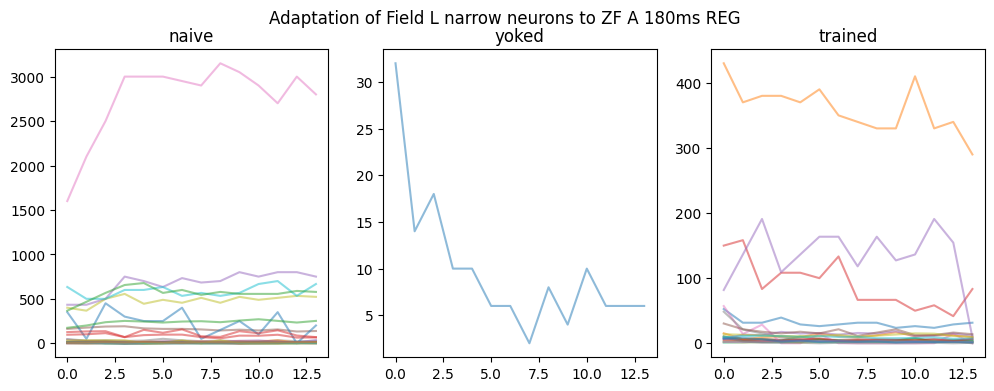

Number of auditory neurons:
trained: 21
yoked: 1
naive: 34


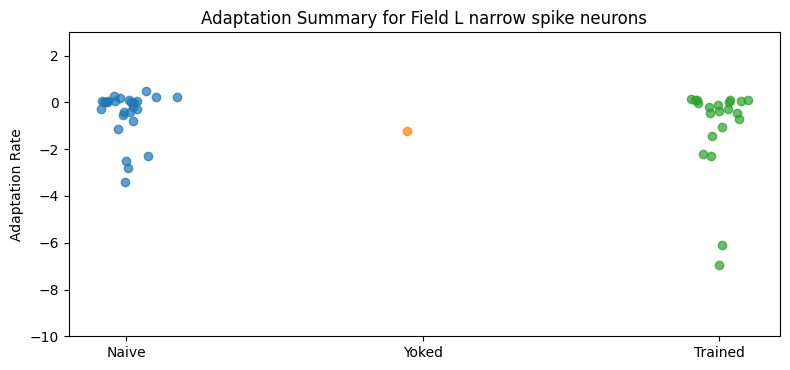

C:\Users\tmerri03\AppData\Local\Temp\ipykernel_40724\2411126953.py:87: RuntimeWarning: invalid value encountered in scalar divide
  btb_df.loc[neuron_counter, u+1] = max_val/baseline_fr
C:\Users\tmerri03\AppData\Local\Temp\ipykernel_40724\2411126953.py:87: RuntimeWarning: invalid value encountered in scalar divide
  btb_df.loc[neuron_counter, u+1] = max_val/baseline_fr


area: Field L, spike_type: broad


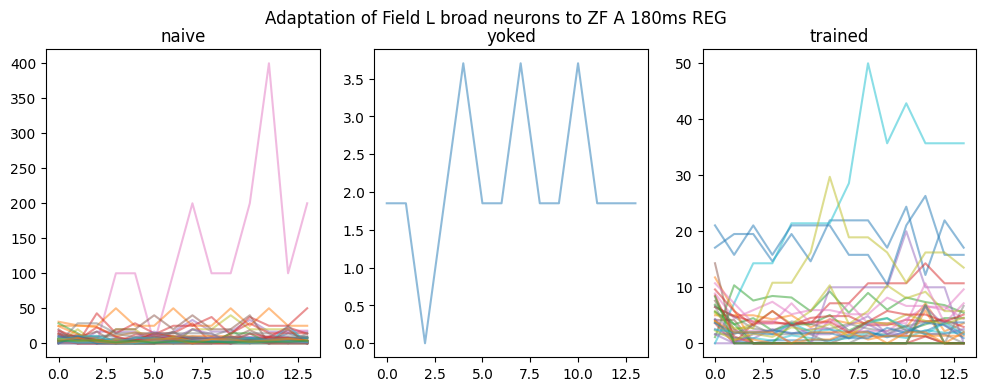

Number of auditory neurons:
trained: 34
yoked: 1
naive: 63


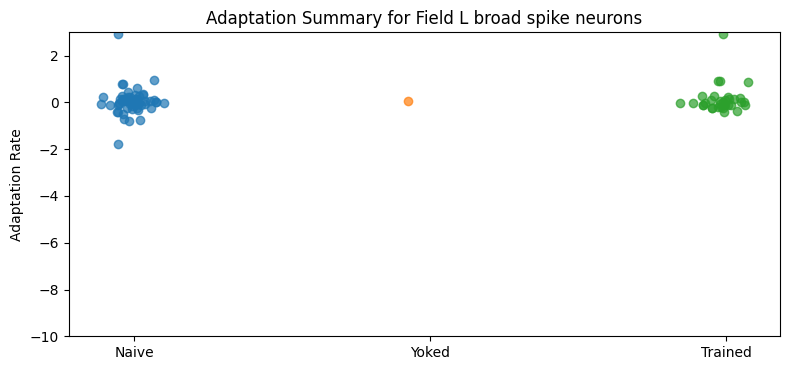

area: NCM, spike_type: narrow


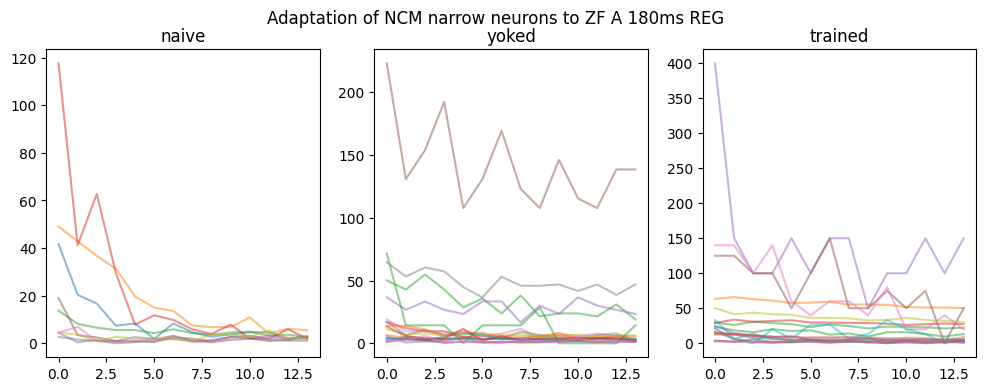

Number of auditory neurons:
trained: 18
yoked: 18
naive: 9


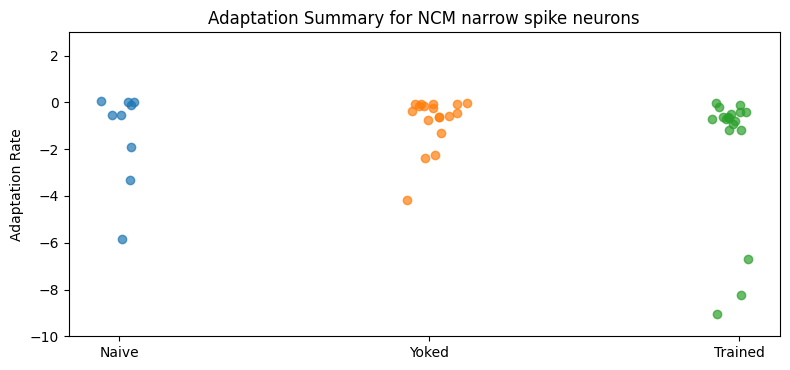

area: NCM, spike_type: broad


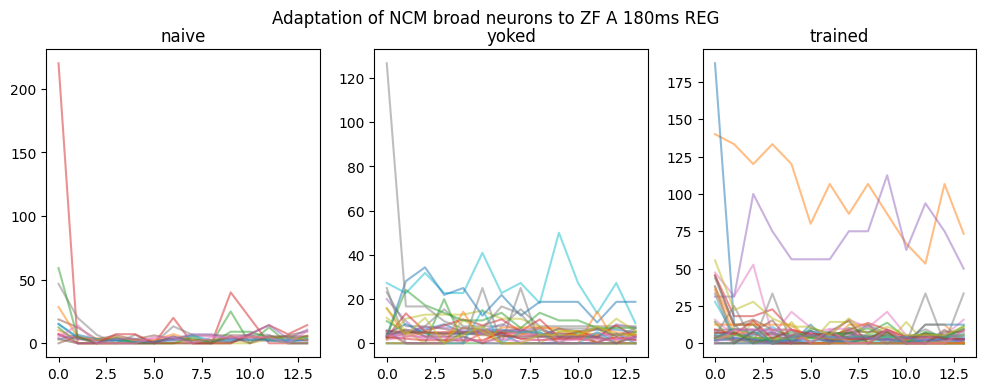

Number of auditory neurons:
trained: 39
yoked: 29
naive: 17


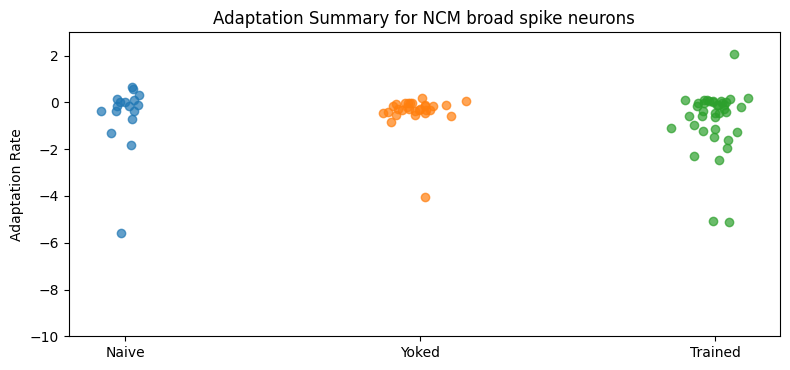

In [37]:
#sort neurons into categories by brain area and firing rate (peak to peak, cutoff @ 0.4ms)
#make plots for trained, yoked, and naive birds
fig_counter = 1

areas = ['Field L', 'NCM']
spike_types = ['narrow', 'broad']
for a, area in enumerate(areas):
    for s, spike_type in enumerate(spike_types):
        neuron_counter = 0
        rec_df = pd.DataFrame(columns=['Session ID', 'spike width'])
        btb_df = pd.DataFrame(columns=[1,2,3,4,5,6,7,8,9,10,11,12,13,14])

        for session_id, unit_id, spike_width_pp, spike_width_hw, spike_file, stimulus_file, status in neurons:
            if status != 'ignore' and area.lower() in session_id.lower():
                if spike_type == 'narrow':
                    cond = (spike_width_pp <= 0.4)
                elif spike_type == 'broad':
                    cond = (spike_width_pp > 0.4)

                if cond:
                    # --- get stimulus ---
                    stim_path = os.path.join(stimulus_file, '..', 'stimuli.json')

                    with open(stim_path, "r") as f:
                        stim_data = pd.DataFrame(json.load(f))

                        windows = stim_data[stim_data['Stimuli Type'] == stimulus].reset_index(drop=True)
                        for r, row in windows.iterrows():
                            start_time = row['Start Time']
                            end_time = row['End Time']

                    # --- get spike times ---
                    data_dict={}
                    with h5py.File(spike_file, "r") as f:
                        for key in f.keys():
                            data_dict[key] = f[key][:]

                    spikes = np.array(data_dict[f'unit_{unit_id}'])/30000

                    all_spks = []
                    all_baseline_spks = []
                    for r, row in windows.iterrows():
                        start_time = row['Start Time']
                        end_time = row['End Time']
                        mask = (spikes >= start_time) & (spikes < end_time)

                        trial_spks = spikes[mask]-start_time
                        all_spks.extend(trial_spks)

                        baseline_start = row['Start Time'] - 1.5
                        baseline_end = row['Start Time'] - 0.5
                        baseline_mask = (spikes >= baseline_start) & (spikes < baseline_end)
                        baseline_spks = spikes[baseline_mask]
                        all_baseline_spks.extend(baseline_spks)

                    # --- find baseline fr ---
                    total_baseline_time = (r+1) * 1 # number of repetitions * length of baseline window for each rep
                    total_baseline_spikes = len(all_baseline_spks)
                    baseline_fr = total_baseline_spikes/total_baseline_time # number of spikes / time = spikes/second

                    bins = np.arange(0, np.max(windows['Duration']) + 10 / 1000, 10 / 1000)
                    counts, edges = np.histogram(sorted(all_spks), bins = bins)
                    counts = counts / len(windows) * 1000 / 10

                    # fig, ax = plt.subplots(1,1, figsize = (8,4))
                    # ax.plot(edges[:-1], counts)

                    for u, up_time in enumerate(up_times):
                        up = up_time - 10/1000
                        down = down_times[u] + 10/1000
                        # ax.axvline(up, color='green', linestyle='dashed')
                        # ax.axvline(down, color='red', linestyle='dashed')

                        mask = (edges[:-1] >= up) & (edges[:-1] <= down)
                        segment = counts[mask]
                        t_seg = edges[:-1][mask]

                        if len(segment) == 0:
                            continue

                        max_val = segment.max()
                        idx_max = segment.argmax()
                        t_max = t_seg[idx_max]

                        # ax.scatter(t_max, max_val)

                        btb_df.loc[neuron_counter, u+1] = max_val/baseline_fr
                        rec_df.loc[neuron_counter, 'Session ID'] = session_id
                        rec_df.loc[neuron_counter, 'spike width'] = spike_width_pp
                    neuron_counter += 1

        btb_df = btb_df.reset_index(drop=True)
        print(f'area: {area}, spike_type: {spike_type}')
        # print(btb_df)

        adaptation_rates, intercepts = plot_adaptation_rates(btb_df, rec_df, trained_birds, yoked_birds, naive_birds, fig_counter, area, spike_type)
        print("Number of auditory neurons:")
        for i in adaptation_rates:
            print(f'{i}: {len(adaptation_rates[i])}')
        plot_summary(adaptation_rates, fig_counter, area, spike_type)
        fig_counter += 1